In [38]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU, BatchNormalization, Dropout
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import h5py
import os
import scipy.io
from scipy.interpolate import interp1d
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import random

# Set seeds for reproducibility
random.seed(42)  # For Python's built-in random module
np.random.seed(42)  # For NumPy
tf.random.set_seed(42)  # For TensorFlow

# Optionally, set TensorFlow to deterministic mode for even more reproducibility
os.environ['TF_DETERMINISTIC_OPS'] = '1'


# --- 1. Data Loading and Initial Reshaping ---

# (All function definitions from your original code are kept here)
# Function to generate file names based on the input format
name_format = "FCNN_Bz_run19_new"
print("Note: use results33.mat which has 10000 datasets; B only has positive Z values")
file_path = os.path.join('MATLAB_DATA', 'results33.mat')  # Replace with your actual file path
def generate_filename(base_name, extension):
    return f"{name_format}_{base_name}.{extension}"


# Define the list of files that should be processed as HDF5 files
h5_file_numbers = {3, 6, 7, 9}

# Function to load data from .h5 file
def load_h5_data(file_path):
    with h5py.File(file_path, 'r') as hdf:
        results_group = hdf['results']
        B_MAG_refs = results_group['B_MAG'][()]
        EDC_MAG_refs = results_group['EDC_MAG'][()]
        X_refs = results_group['X'][()]
        I_refs = results_group['I'][()]
        B_MAG_raw = [hdf[ref][()] for ref in B_MAG_refs.flatten()]
        EDC_MAG_raw = [hdf[ref][()] for ref in EDC_MAG_refs.flatten()]
        X_raw = [hdf[ref][()] for ref in X_refs.flatten()]
        I_raw = [hdf[ref][()] for ref in I_refs.flatten()]
    return B_MAG_raw, EDC_MAG_raw, X_raw, I_raw

# Function to load data from .mat file
def load_mat_data(file_path):
    mat_contents = scipy.io.loadmat(file_path)
    results = mat_contents['results']
    B_MAG_raw = [result['B_MAG'][0] for result in results[0]]
    EDC_MAG_raw = [result['EDC_MAG'][0] for result in results[0]]
    X_raw = [result['X'][0] for result in results[0]]  # Scaling X values
    I_raw = [result['I'][0] for result in results[0]]
    return B_MAG_raw, EDC_MAG_raw, X_raw, I_raw

# Function to resample and smooth data
def resample_and_smooth(X, I, new_length):
    X_new = np.linspace(6562.3, 6563.3, num=new_length)
    f = interp1d(X, I, kind='cubic', fill_value="extrapolate")
    I_new = f(X_new)
    return X_new, I_new

# Function to process data
def process_data(B_MAG_raw, EDC_MAG_raw, X_raw, I_raw, fixed_length=1200):
    X_data, I_data, B_MAG_data, EDC_MAG_data = [], [], [], []
    for i in range(len(X_raw)):
        X = np.squeeze(X_raw[i])
        I = np.squeeze(I_raw[i])
        B = np.squeeze(B_MAG_raw[i])
        EDC = np.squeeze(EDC_MAG_raw[i])
        X_scaled = X * 10**10
        X_resampled, I_resampled = resample_and_smooth(X_scaled, I, fixed_length)
        X_data.append(X_resampled)
        I_data.append(I_resampled)
        B_MAG_data.append(B)
        EDC_MAG_data.append(EDC)
    return np.array(B_MAG_data), np.array(EDC_MAG_data), np.array(X_data), np.array(I_data)

# Main function to determine the type of file and load data accordingly
def load_and_process_file(file_path):
    file_name = os.path.basename(file_path)
    
    # Extract the file number (e.g., results1, results5, etc.)
    file_number = int(file_name.lstrip('results').rstrip('.mat'))
    
    if file_number in h5_file_numbers:
        # It's an HDF5 file
        print(f"Processing {file_name} as an HDF5 file...", flush=True)
        B_MAG_raw, EDC_MAG_raw, X_raw, I_raw = load_h5_data(file_path)
    else:
        # It's a standard .mat file
        print(f"Processing {file_name} as a .mat file...", flush=True)
        B_MAG_raw, EDC_MAG_raw, X_raw, I_raw = load_mat_data(file_path)
    
    # Process the loaded data
    B_MAG_data, EDC_MAG_data, X_data, I_data = process_data(B_MAG_raw, EDC_MAG_raw, X_raw, I_raw)
    
    return B_MAG_data, EDC_MAG_data, X_data, I_data

B_MAG_data, EDC_MAG_data, X_data, I_data = load_and_process_file(file_path)
print("Data loading and resampling completed.")

# Combine target variables before splitting
target_data_raw = np.column_stack((B_MAG_data[:, 2], EDC_MAG_data))
input_data_raw = I_data

# --- 2. Train-Test Split (Applied BEFORE any normalization/scaling) ---
input_train_raw, input_test_raw, target_train_raw, target_test_raw = train_test_split(
    input_data_raw, target_data_raw, test_size=0.2, random_state=42
)
print(f"Data split into {len(input_train_raw)} training samples and {len(input_test_raw)} testing samples.")

# --- 3. Input Data Preprocessing (Z-Score Normalization) ---

# Calculate std dev for filtering *only* from the training set to find the feature window
stds_train = np.std(input_train_raw, axis=0)
start_index, end_index = 0, input_train_raw.shape[1] - 1
for i in range(input_train_raw.shape[1]):
    if stds_train[i] >= 0.01:
        start_index = i
        break
for i in range(input_train_raw.shape[1] - 1, -1, -1):
    if stds_train[i] >= 0.01:
        end_index = i
        break
print(f"Input data will be filtered from column {start_index} to {end_index} based on training set variance.")

# Apply the same fixed window to both train and test sets
I_train_filtered = input_train_raw[:, start_index:end_index + 1]
I_test_filtered = input_test_raw[:, start_index:end_index + 1]

# Calculate mean and std for normalization *only* from the filtered training set
means_train_filtered = np.mean(I_train_filtered, axis=0)
stds_train_filtered = np.std(I_train_filtered, axis=0)

# Apply the z-score transformation to both sets using the parameters from the training set
normalized_I_train = (I_train_filtered - means_train_filtered) / stds_train_filtered
normalized_I_test = (I_test_filtered - means_train_filtered) / stds_train_filtered

# This function is now used to interpolate the filtered data back to a fixed length of 1200
def interpolate_to_fixed_length(data, new_length=1200):
    resampled_data = []
    for row in data:
        x_original = np.linspace(0, 1, num=len(row))
        x_new = np.linspace(0, 1, num=new_length)
        f = interp1d(x_original, row, kind='cubic', fill_value="extrapolate")
        resampled_data.append(f(x_new))
    return np.array(resampled_data)

normalized_I_resampled_train = interpolate_to_fixed_length(normalized_I_train)
normalized_I_resampled_test = interpolate_to_fixed_length(normalized_I_test)

# Flatten the final input data
I_train = normalized_I_resampled_train.reshape(normalized_I_resampled_train.shape[0], -1)
I_test = normalized_I_resampled_test.reshape(normalized_I_resampled_test.shape[0], -1)

print("Input (z-score) preprocessing complete.")


# --- 4. Target Data Preprocessing (MinMax Scaling) ---

# Separate the raw target components for both train and test sets
B_train = target_train_raw[:, 0:1]
E_train = target_train_raw[:, 1:]
B_test = target_test_raw[:, 0:1]
E_test = target_test_raw[:, 1:]

# Initialize scalers
scaler_B3 = MinMaxScaler()
scaler_E1 = MinMaxScaler()
scaler_E2 = MinMaxScaler()
scaler_E3 = MinMaxScaler()

# Fit and transform the TRAINING data components
B_train_scaled = scaler_B3.fit_transform(B_train)
E_train_scaled = np.column_stack((
    scaler_E1.fit_transform(E_train[:, 0].reshape(-1, 1)),
    scaler_E2.fit_transform(E_train[:, 1].reshape(-1, 1)),
    scaler_E3.fit_transform(E_train[:, 2].reshape(-1, 1))
))

# ONLY transform the TESTING data components using the scalers fit on the training data
B_test_scaled = scaler_B3.transform(B_test)
E_test_scaled = np.column_stack((
    scaler_E1.transform(E_test[:, 0].reshape(-1, 1)),
    scaler_E2.transform(E_test[:, 1].reshape(-1, 1)),
    scaler_E3.transform(E_test[:, 2].reshape(-1, 1))
))

# Recombine the scaled components into the final target data arrays
target_train_scaled = np.column_stack((B_train_scaled, E_train_scaled))
target_test_scaled = np.column_stack((B_test_scaled, E_test_scaled))

Note: use results33.mat which has 10000 datasets; B only has positive Z values
Processing results33.mat as a .mat file...
Data loading and resampling completed.
Data split into 8000 training samples and 2000 testing samples.
Input data will be filtered from column 363 to 864 based on training set variance.
Input (z-score) preprocessing complete.


In [39]:
from tensorflow.keras.callbacks import Callback
class LossMonitor(Callback):
    def on_batch_end(self, batch, logs=None):
        if batch % 100 == 0:
            print(f"Batch {batch}: loss = {logs['loss']}")

In [40]:
# Define the model
model = Sequential([
    # Reduced dropout and regularization, introduced Swish activation
    Dense(512, kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.2),  # Reduced dropout further
    
    Dense(256, kernel_regularizer=l2(0.0003)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.2),
    
    Dense(128, kernel_regularizer=l2(0.0001)),  # Reduced regularization in the later layers
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.1),  # Minimal dropout for smaller layer
    
    Dense(64, kernel_regularizer=l2(0.0001), activation='swish'),
    Dropout(0.1),  # Further reduced dropout
    
    Dense(32, activation='swish'), # No regularization, small dropout for the final layer
    
    Dense(16, activation='swish'),

    Dense(4)  # Output layer
])

In [41]:
def custom_loss(y_true, y_pred):
    B_true, E_true = y_true[:, :1], y_true[:, 1:]
    B_pred, E_pred = y_pred[:, :1], y_pred[:, 1:]
    loss_B = tf.reduce_mean(tf.square(B_true - B_pred), axis=0)
    loss_E = tf.reduce_mean(tf.square(E_true - E_pred), axis=0)
    weight_B = tf.constant([1.0])
    weight_E = tf.constant([1.0, 1.0, 1.0])
    total_loss = tf.reduce_sum(weight_B * loss_B) + tf.reduce_sum(weight_E * loss_E)
    return total_loss

In [42]:
# Compile the model
model.compile(optimizer=RMSprop(learning_rate=0.0005), loss=custom_loss, metrics=['mse'])

In [43]:
# Define learning rate scheduler and early stopping
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

In [44]:
# Train the model
# history = model.fit(
#     I_train, 
#     target_train_scaled, 
#     epochs=400, 
#     batch_size=32, 
#     validation_split=0.2, 
#     callbacks=[lr_scheduler, early_stopping, LossMonitor()]
# )

In [45]:
# Save the tested model
model_save_path = os.path.join("/home/botingl/machine learning copy", generate_filename("model", "h5"))
# model.save(model_save_path)
print("Model saved successfully.")

Model saved successfully.


In [46]:
# Load the model
model = tf.keras.models.load_model(model_save_path, custom_objects={'custom_loss': custom_loss})
print("Model loaded successfully.")

Model loaded successfully.


In [47]:
# Whole model evaluation (NMSE, rMAE, R²)
def evaluate_whole_model(y_true, y_pred):
    nmse = mean_squared_error(y_true, y_pred) / np.var(y_true)
    rmae = mean_absolute_error(y_true, y_pred) / np.mean(np.abs(y_true))
    r2 = r2_score(y_true, y_pred)
    return nmse, rmae, r2

In [48]:
# Component-wise evaluation (MSE, MAE, R²)
def evaluate_components(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mse, mae, r2

In [49]:
# Evaluation metrics for the testing data
print("Start to evaluate the training set.", flush=True)
# Set size based on the length of I_train
# size = len(I_train) if len(I_train) < 1000 else 1000
size = len(I_train) if len(I_train) < 8000 else 8000
train_subset_indices = np.random.choice(len(I_train), size=size, replace=False)
train_input_data_subset = I_train[train_subset_indices]
train_target_data_subset = target_train_scaled[train_subset_indices]

Start to evaluate the training set.


In [50]:
predictions_train = model.predict(train_input_data_subset)

250/250 [==============================] - 2s 6ms/step


In [51]:
num_input = len(train_input_data_subset)

In [52]:
# Scale back the predicted values to original range
B_pred_train = scaler_B3.inverse_transform(predictions_train[:, 0].reshape(-1, 1))
E_pred_train = np.column_stack((
    scaler_E1.inverse_transform(predictions_train[:, 1].reshape(-1, 1)),
    scaler_E2.inverse_transform(predictions_train[:, 2].reshape(-1, 1)),
    scaler_E3.inverse_transform(predictions_train[:, 3].reshape(-1, 1))
))

In [53]:
# Scale back the true values to original range
B_true_train = scaler_B3.inverse_transform(train_target_data_subset[:, 0].reshape(-1, 1))
E_true_train = np.column_stack((
    scaler_E1.inverse_transform(train_target_data_subset[:, 1].reshape(-1, 1)),
    scaler_E2.inverse_transform(train_target_data_subset[:, 2].reshape(-1, 1)),
    scaler_E3.inverse_transform(train_target_data_subset[:, 3].reshape(-1, 1))
))

In [54]:
# Combine the scaled-back true and predicted values for evaluation
true_train_combined = np.column_stack((B_true_train, E_true_train))
pred_train_combined = np.column_stack((B_pred_train, E_pred_train))

In [55]:
# Whole model evaluation
nmse_train, rmae_train, r2_whole_model_train = evaluate_whole_model(true_train_combined, pred_train_combined)
print(f"Whole Model NMSE: {nmse_train}, rMAE: {rmae_train}, R²: {r2_whole_model_train}")

Whole Model NMSE: 0.01524552648893313, rMAE: 0.05587088542296532, R²: 0.9796592116957316


In [56]:
# Component-wise evaluation
mse_train_B3, mae_train_B3, r2_train_B3 = evaluate_components(B_true_train, B_pred_train)
mse_train_E1, mae_train_E1, r2_train_E1 = evaluate_components(E_true_train[:, 0], E_pred_train[:, 0])
mse_train_E2, mae_train_E2, r2_train_E2 = evaluate_components(E_true_train[:, 1], E_pred_train[:, 1])
mse_train_E3, mae_train_E3, r2_train_E3 = evaluate_components(E_true_train[:, 2], E_pred_train[:, 2])

In [57]:
# Output the evaluation for each component
print(f"B3: MSE = {mse_train_B3}, MAE = {mae_train_B3}, R² = {r2_train_B3}")
print(f"E1: MSE = {mse_train_E1}, MAE = {mae_train_E1}, R² = {r2_train_E1}")
print(f"E2: MSE = {mse_train_E2}, MAE = {mae_train_E2}, R² = {r2_train_E2}")
print(f"E3: MSE = {mse_train_E3}, MAE = {mae_train_E3}, R² = {r2_train_E3}")

B3: MSE = 1.5549129539668268e-05, MAE = 0.003122085677015478, R² = 0.997915830616005
E1: MSE = 781.9235749112652, MAE = 17.082773491826156, R² = 0.9632045506389441
E2: MSE = 182.89440171073036, MAE = 9.597312994993988, R² = 0.9912061341713422
E3: MSE = 702.721515387514, MAE = 15.07160918193003, R² = 0.9663103313566348


In [58]:
# Save evaluation metrics to a text file
metrics_train_file = os.path.join("/home/botingl/machine learning copy", generate_filename("evaluation_metrics_train", "txt"))
with open(metrics_train_file, "w") as f:
    f.write(f"Whole Model: NMSE: {nmse_train}, rMAE: {rmae_train}, R²: {r2_whole_model_train}\n")
    f.write(f"B3: MSE = {mse_train_B3}, MAE = {mae_train_B3}, R² = {r2_train_B3}\n")
    f.write(f"E1: MSE = {mse_train_E1}, MAE = {mae_train_E1}, R² = {r2_train_E1}\n")
    f.write(f"E2: MSE = {mse_train_E2}, MAE = {mae_train_E2}, R² = {r2_train_E2}\n")
    f.write(f"E3: MSE = {mse_train_E3}, MAE = {mae_train_E3}, R² = {r2_train_E3}\n")

In [59]:
print("Training set evaluation done.", flush=True)

Training set evaluation done.


In [60]:
# Evaluate the model on the testing set
print("Start to evaluate the testing set.", flush=True)

Start to evaluate the testing set.


In [61]:
predictions_test = model.predict(I_test)

63/63 [==============================] - 1s 4ms/step


In [62]:
# Scale back the predicted values to original range for the test data
B_pred_test = scaler_B3.inverse_transform(predictions_test[:, 0].reshape(-1, 1))

In [63]:
E_pred_test = np.column_stack((
    scaler_E1.inverse_transform(predictions_test[:, 1].reshape(-1, 1)),
    scaler_E2.inverse_transform(predictions_test[:, 2].reshape(-1, 1)),
    scaler_E3.inverse_transform(predictions_test[:, 3].reshape(-1, 1))
))

In [64]:
# Scale back the true values to original range for the test data
B_true_test = scaler_B3.inverse_transform(target_test_scaled[:, 0].reshape(-1, 1))

In [65]:
E_true_test = np.column_stack((
    scaler_E1.inverse_transform(target_test_scaled[:, 1].reshape(-1, 1)),
    scaler_E2.inverse_transform(target_test_scaled[:, 2].reshape(-1, 1)),
    scaler_E3.inverse_transform(target_test_scaled[:, 3].reshape(-1, 1))
))

In [66]:
# Combine the scaled-back true and predicted values for evaluation (test data)
true_test_combined = np.column_stack((B_true_test, E_true_test))
pred_test_combined = np.column_stack((B_pred_test, E_pred_test))

In [67]:
# Whole model evaluation
nmse_test, rmae_test, r2_whole_model_test = evaluate_whole_model(true_test_combined, pred_test_combined)
print(f"Whole Model NMSE: {nmse_test}, rMAE: {rmae_test}, R²: {r2_whole_model_test}")

Whole Model NMSE: 0.01707678923331455, rMAE: 0.05863251113150782, R²: 0.9772488967193496


In [68]:
# Component-wise evaluation
mse_test_B3, mae_test_B3, r2_test_B3 = evaluate_components(B_true_test, B_pred_test)
mse_test_E1, mae_test_E1, r2_test_E1 = evaluate_components(E_true_test[:, 0], E_pred_test[:, 0])
mse_test_E2, mae_test_E2, r2_test_E2 = evaluate_components(E_true_test[:, 1], E_pred_test[:, 1])
mse_test_E3, mae_test_E3, r2_test_E3 = evaluate_components(E_true_test[:, 2], E_pred_test[:, 2])

In [69]:
# Output the evaluation for each component
print(f"B3: MSE = {mse_test_B3}, MAE = {mae_test_B3}, R² = {r2_test_B3}")
print(f"E1: MSE = {mse_test_E1}, MAE = {mae_test_E1}, R² = {r2_test_E1}")
print(f"E2: MSE = {mse_test_E2}, MAE = {mae_test_E2}, R² = {r2_test_E2}")
print(f"E3: MSE = {mse_test_E3}, MAE = {mae_test_E3}, R² = {r2_test_E3}")

B3: MSE = 1.6505325484246186e-05, MAE = 0.0032316386595883876, R² = 0.9977327447689573
E1: MSE = 849.9569934941782, MAE = 17.40018429735886, R² = 0.960638387061708
E2: MSE = 222.10545143805854, MAE = 10.47035925079184, R² = 0.9892130692277284
E3: MSE = 803.1014409039304, MAE = 16.044801104077102, R² = 0.9614113858190043


In [70]:
# Save evaluation metrics to a text file
metrics_train_file = os.path.join("/home/botingl/machine learning copy", generate_filename("evaluation_metrics_test", "txt"))
with open(metrics_train_file, "w") as f:
    f.write(f"Whole Model: NMSE: {nmse_test}, rMAE: {rmae_test}, R²: {r2_whole_model_test}\n")
    f.write(f"B3: MSE = {mse_test_B3}, MAE = {mae_test_B3}, R² = {r2_test_B3}\n")
    f.write(f"E1: MSE = {mse_test_E1}, MAE = {mae_test_E1}, R² = {r2_test_E1}\n")
    f.write(f"E2: MSE = {mse_test_E2}, MAE = {mae_test_E2}, R² = {r2_test_E2}\n")
    f.write(f"E3: MSE = {mse_test_E3}, MAE = {mae_test_E3}, R² = {r2_test_E3}\n")

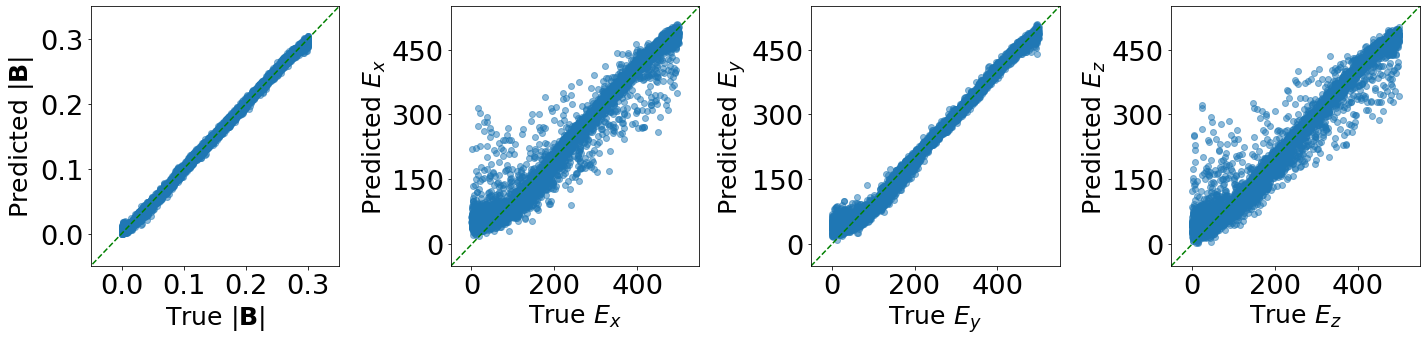

Training set evaluation done.


In [71]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os

# Define a global font scaling factor
scale = 2.1 

# Base font sizes
base_label = 12
base_suptitle = 14
base_ticks = 13

plt.figure(figsize=(20, 5))

# --- B3 ---
ax1 = plt.subplot(1, 4, 1)
ax1.scatter(B_true_train, B_pred_train, alpha=0.5)
ax1.plot([-0.1, 1.1], [-0.1, 1.1], 'g--')
ax1.set_xlim(-0.05, 0.35)
ax1.set_ylim(-0.05, 0.35)
ax1.set_xlabel('True $|\\mathbf{B}|$', fontsize=base_label*scale)
ax1.set_ylabel('Predicted $|\\mathbf{B}|$', fontsize=base_label*scale)
ax1.tick_params(labelsize=base_ticks*scale)
# Reduce x ticks only for the first subplot
ax1.xaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
# Reduce y ticks
ax1.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4))

# --- E1 ---
ax2 = plt.subplot(1, 4, 2)
ax2.scatter(E_true_train[:, 0], E_pred_train[:, 0], alpha=0.5)
ax2.plot([-50, 550], [-50, 550], 'g--')
ax2.set_xlim(-50, 550)
ax2.set_ylim(-50, 550)
ax2.set_xlabel('True $E_x$', fontsize=base_label*scale)
ax2.set_ylabel('Predicted $E_x$', fontsize=base_label*scale)
ax2.tick_params(labelsize=base_ticks*scale)
# Reduce y ticks
ax2.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
# ax2.ticklabel_format(style='sci', axis='both', scilimits=(0,0))
# ax2.xaxis.get_offset_text().set_fontsize(base_ticks*scale*0.8)
# ax2.yaxis.get_offset_text().set_fontsize(base_ticks*scale*0.8)


# --- E2 ---
ax3 = plt.subplot(1, 4, 3)
ax3.scatter(E_true_train[:, 1], E_pred_train[:, 1], alpha=0.5)
ax3.plot([-50, 550], [-50, 550], 'g--')
ax3.set_xlim(-50, 550)
ax3.set_ylim(-50, 550)
ax3.set_xlabel('True $E_y$', fontsize=base_label*scale)
ax3.set_ylabel('Predicted $E_y$', fontsize=base_label*scale)
ax3.tick_params(labelsize=base_ticks*scale)
# Reduce y ticks
ax3.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
# ax3.ticklabel_format(style='sci', axis='both', scilimits=(0,0))
# ax3.xaxis.get_offset_text().set_fontsize(base_ticks*scale*0.8)
# ax3.yaxis.get_offset_text().set_fontsize(base_ticks*scale*0.8)

# --- E3 ---
ax4 = plt.subplot(1, 4, 4)
ax4.scatter(E_true_train[:, 2], E_pred_train[:, 2], alpha=0.5)
ax4.plot([-50, 550], [-50, 550], 'g--')
ax4.set_xlim(-50, 550)
ax4.set_ylim(-50, 550)
ax4.set_xlabel('True $E_z$', fontsize=base_label*scale)
ax4.set_ylabel('Predicted $E_z$', fontsize=base_label*scale)
ax4.tick_params(labelsize=base_ticks*scale)
# Reduce y ticks
ax4.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
# ax4.ticklabel_format(style='sci', axis='both', scilimits=(0,0))
# ax4.xaxis.get_offset_text().set_fontsize(base_ticks*scale*0.8)
# ax4.yaxis.get_offset_text().set_fontsize(base_ticks*scale*0.8)

# Figure title
# plt.suptitle('True vs. Predicted Components Using FCNN (Training Data)', fontsize=base_suptitle*scale)

# Layout & save
plt.tight_layout(rect=[0, 0, 1, 0.97])
figure_train_file = os.path.join("/home/botingl/machine learning copy/Plots", 
                                 generate_filename("true_vs_predictions_train", "pdf"))
plt.savefig(figure_train_file, dpi=300, facecolor='white')
plt.show()

print("Training set evaluation done.", flush=True)


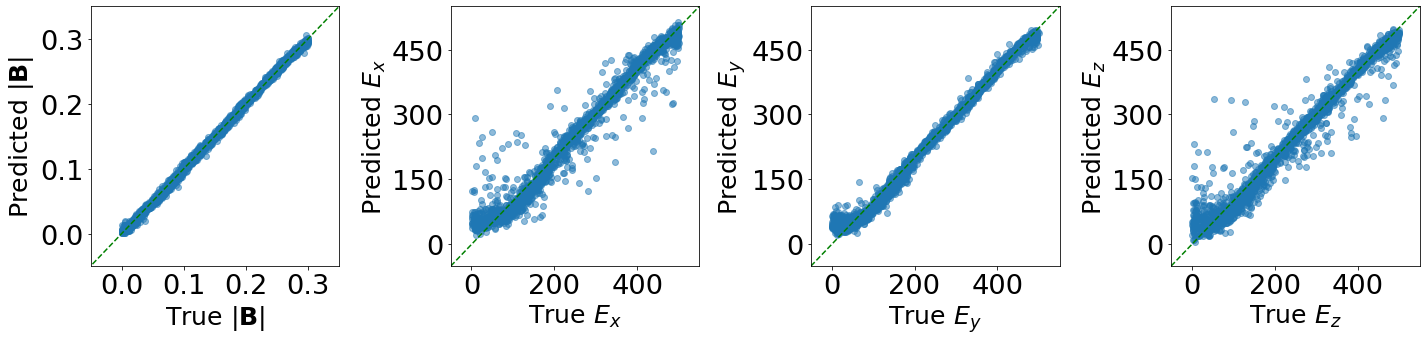

Testing set evaluation done.


In [72]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os

# Define a global font scaling factor
scale = 2.1

# Base font sizes
base_label = 12
base_suptitle = 14
base_ticks = 13

plt.figure(figsize=(20, 5))

# --- B3 ---
ax1 = plt.subplot(1, 4, 1)
ax1.scatter(B_true_test, B_pred_test, alpha=0.5)
ax1.plot([-0.1, 1.1], [-0.1, 1.1], 'g--')
ax1.set_xlim(-0.05, 0.35)
ax1.set_ylim(-0.05, 0.35)
ax1.set_xlabel('True $|\mathbf{B}|$', fontsize=base_label*scale)
ax1.set_ylabel('Predicted $|\mathbf{B}|$', fontsize=base_label*scale)
ax1.tick_params(labelsize=base_ticks*scale)
# Reduce x ticks only for the first subplot
ax1.xaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
# Reduce y ticks
ax1.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4))

# --- E1 ---
ax2 = plt.subplot(1, 4, 2)
ax2.scatter(E_true_test[:, 0], E_pred_test[:, 0], alpha=0.5)
ax2.plot([-50, 550], [-50, 550], 'g--')
ax2.set_xlim(-50, 550)
ax2.set_ylim(-50, 550)
ax2.set_xlabel('True $E_x$', fontsize=base_label*scale)
ax2.set_ylabel('Predicted $E_x$', fontsize=base_label*scale)
ax2.tick_params(labelsize=base_ticks*scale)
# Reduce y ticks
ax2.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
# ax2.ticklabel_format(style='sci', axis='both', scilimits=(0,0))
# ax2.xaxis.get_offset_text().set_fontsize(base_ticks*scale*0.8)
# ax2.yaxis.get_offset_text().set_fontsize(base_ticks*scale*0.8)

# --- E2 ---
ax3 = plt.subplot(1, 4, 3)
ax3.scatter(E_true_test[:, 1], E_pred_test[:, 1], alpha=0.5)
ax3.plot([-50, 550], [-50, 550], 'g--')
ax3.set_xlim(-50, 550)
ax3.set_ylim(-50, 550)
ax3.set_xlabel('True $E_y$', fontsize=base_label*scale)
ax3.set_ylabel('Predicted $E_y$', fontsize=base_label*scale)
ax3.tick_params(labelsize=base_ticks*scale)
# Reduce y ticks
ax3.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
# ax3.ticklabel_format(style='sci', axis='both', scilimits=(0,0))
# ax3.xaxis.get_offset_text().set_fontsize(base_ticks*scale*0.8)
# ax3.yaxis.get_offset_text().set_fontsize(base_ticks*scale*0.8)


# --- E3 ---
ax4 = plt.subplot(1, 4, 4)
ax4.scatter(E_true_test[:, 2], E_pred_test[:, 2], alpha=0.5)
ax4.plot([-50, 550], [-50, 550], 'g--')
ax4.set_xlim(-50, 550)
ax4.set_ylim(-50, 550)
ax4.set_xlabel('True $E_z$', fontsize=base_label*scale)
ax4.set_ylabel('Predicted $E_z$', fontsize=base_label*scale)
ax4.tick_params(labelsize=base_ticks*scale)
# Reduce y ticks
ax4.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
# ax4.ticklabel_format(style='sci', axis='both', scilimits=(0,0))
# ax4.xaxis.get_offset_text().set_fontsize(base_ticks*scale*0.8)
# ax4.yaxis.get_offset_text().set_fontsize(base_ticks*scale*0.8)


# Figure title
# plt.suptitle('True vs. Predicted Components Using FCNN (Testing Data)', fontsize=base_suptitle*scale)

# Layout & save
plt.tight_layout(rect=[0, 0, 1, 0.97])
figure_test_file = os.path.join("/home/botingl/machine learning copy/Plots", 
                                generate_filename("true_vs_predictions_test", "pdf"))
plt.savefig(figure_test_file, dpi=300, facecolor='white')
plt.show()

print("Testing set evaluation done.", flush=True)


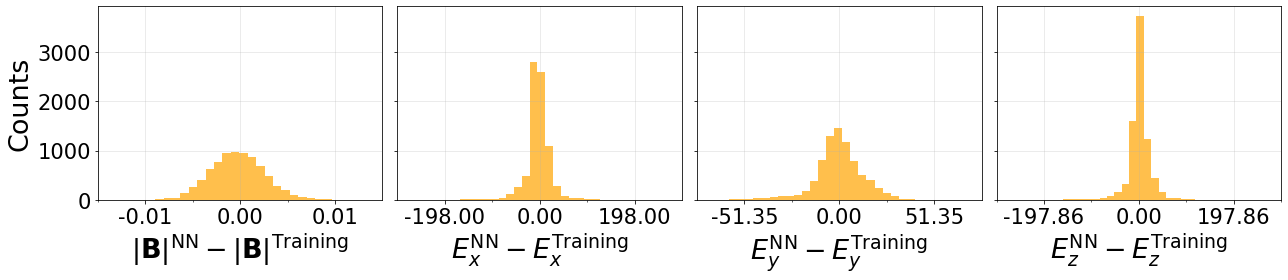

In [73]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import FormatStrFormatter

# Adjustable font sizes
scale = 1.5
label_fontsize = int(18 * scale)
tick_fontsize  = int(14 * scale)

# Errors (assumed already defined)
B3_error_train = B_true_train - B_pred_train
E1_error_train = E_true_train[:, 0] - E_pred_train[:, 0]
E2_error_train = E_true_train[:, 1] - E_pred_train[:, 1]
E3_error_train = E_true_train[:, 2] - E_pred_train[:, 2]

data_list = [
    (B3_error_train, r'$|\mathbf{B}|^{\mathrm{NN}} - |\mathbf{B}|^{\mathrm{Training}}$'),
    (E1_error_train, r'$E_x^{\mathrm{NN}} - E_x^{\mathrm{Training}}$'),
    (E2_error_train, r'$E_y^{\mathrm{NN}} - E_y^{\mathrm{Training}}$'),
    (E3_error_train, r'$E_z^{\mathrm{NN}} - E_z^{\mathrm{Training}}$')
]

fig, axs = plt.subplots(1, 4, figsize=(18, 4), sharey=True)

for i, (data, xlabel) in enumerate(data_list):
    ax = axs[i]
    ax.hist(data, bins=30, color='orange', alpha=0.7)
    ax.set_xlabel(xlabel, fontsize=label_fontsize)
    if i == 0:
        ax.set_ylabel('Counts', fontsize=label_fontsize)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='both', which='both', labelsize=tick_fontsize)

    # --- force symmetry around zero, subplot by subplot ---
    lim = np.max(np.abs([data.min(), data.max()]))
    ax.set_xlim(-lim, lim)

    # Make x ticks denser: about 6–8 major ticks
    step = (2 * lim) / 3.0
    ax.xaxis.set_major_locator(ticker.MultipleLocator(step))
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))

    # --- format x ticks with two decimals ---
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))


plt.tight_layout()
plt.savefig("/home/botingl/machine learning copy/Plots/FCNN_training_histogram.pdf", dpi=300, facecolor='white')
plt.show()


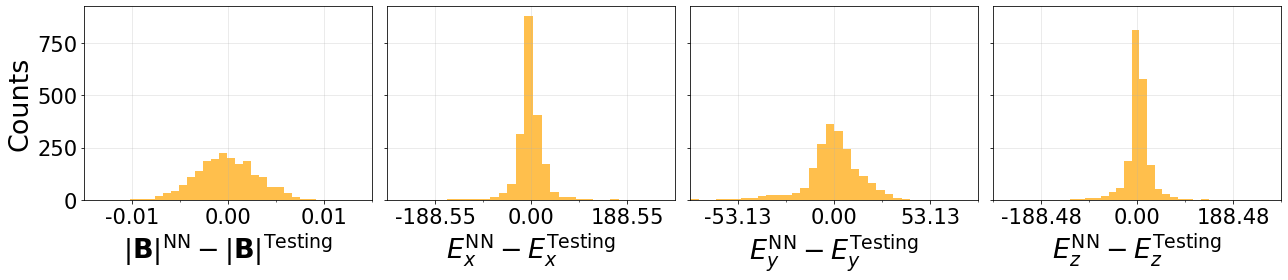

In [74]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import FormatStrFormatter

# Adjustable font sizes
scale = 1.5
label_fontsize = int(18 * scale)
tick_fontsize  = int(14 * scale)

# Errors (assumed already defined)
B3_error_test = B_true_test - B_pred_test
E1_error_test = E_true_test[:, 0] - E_pred_test[:, 0]
E2_error_test = E_true_test[:, 1] - E_pred_test[:, 1]
E3_error_test = E_true_test[:, 2] - E_pred_test[:, 2]

data_list = [
    (B3_error_test, r'$|\mathbf{B}|^{\mathrm{NN}} - |\mathbf{B}|^{\mathrm{Testing}}$'),
    (E1_error_test, r'$E_x^{\mathrm{NN}} - E_x^{\mathrm{Testing}}$'),
    (E2_error_test, r'$E_y^{\mathrm{NN}} - E_y^{\mathrm{Testing}}$'),
    (E3_error_test, r'$E_z^{\mathrm{NN}} - E_z^{\mathrm{Testing}}$')
]

fig, axs = plt.subplots(1, 4, figsize=(18, 4), sharey=True)

for i, (data, xlabel) in enumerate(data_list):
    ax = axs[i]
    ax.hist(data, bins=30, color='orange', alpha=0.7)
    ax.set_xlabel(xlabel, fontsize=label_fontsize)
    if i == 0:
        ax.set_ylabel('Counts', fontsize=label_fontsize)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='both', which='both', labelsize=tick_fontsize)

    # --- force symmetry around zero, subplot by subplot ---
    lim = np.max(np.abs([data.min(), data.max()]))
    ax.set_xlim(-lim, lim)

    # Make x ticks denser: about 6–8 major ticks
    step = (2 * lim) / 3.0
    ax.xaxis.set_major_locator(ticker.MultipleLocator(step))
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))

    # --- format x ticks with two decimals ---
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))


plt.tight_layout()
plt.savefig("/home/botingl/machine learning copy/Plots/FCNN_testing_histogram.pdf", dpi=300, facecolor='white')
plt.show()
